# 📈 TSLA Stock Analysis — Week 1 Internship Project

**Dataset:** Real TSLA data from `April 12, 2011` → `May 23, 2023` (3,049 trading days)

## Steps in this Notebook:
1. Load CSV → keep only `Date` and `Adj Close`
2. Add `% change` column (daily % change)
3. Add `1monthchange` column (placed only on last trading day of each month)
4. Save processed data to `TSLA_processed.csv`
5. Extract last 24 months of data
6. Plot bar chart with matplotlib
7. Summary statistics

---
## STEP 1: Import Libraries

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import os

print('✅ Libraries imported!')

✅ Libraries imported!


---
## STEP 2: Load CSV — Keep Only Date & Adj Close
The original file has 7 columns: `Date, Open, High, Low, Close, Adj Close, Volume`  
We only need `Date` and `Adj Close` as per the task.

In [4]:
# Load full CSV first to see all columns
df_raw = pd.read_csv('TSLA_processed.csv')
print('Original columns:', df_raw.columns.tolist())
print('Total rows:', len(df_raw))
print()

# Keep ONLY Date and Adj Close
df = df_raw[['Date', 'Adj Close']].copy()

# Convert Date to proper datetime format (needed for groupby month)
df['Date'] = pd.to_datetime(df['Date'])

# Sort oldest → newest
df = df.sort_values('Date').reset_index(drop=True)

print('✅ Extracted Date & Adj Close only!')
print(f'Date range: {df["Date"].min().date()} → {df["Date"].max().date()}')
df.head(10)

Original columns: ['Date', 'Adj Close', '% change', '1monthchange']
Total rows: 3049

✅ Extracted Date & Adj Close only!
Date range: 2011-04-12 → 2023-05-23


,Date,Adj Close
0,2011-04-12,1.643333
1,2011-04-13,1.662000
2,2011-04-14,1.676000
3,2011-04-15,1.705333
4,2011-04-18,1.668667
5,2011-04-19,1.677333
6,2011-04-20,1.716667
7,2011-04-21,1.782667
8,2011-04-25,1.759333
9,2011-04-26,1.795333


---
## STEP 3: Add % change Column (Daily % Change)

**Formula:** `% change = ((today - yesterday) / yesterday) × 100`

`pct_change()` computes this automatically. First row = NaN (no previous day).

In [5]:
df['% change'] = (df['Adj Close'].pct_change() * 100).round(4)

print('✅ Daily % change column added!')
print('First row is NaN — no previous day exists for comparison')
df.head(8)

✅ Daily % change column added!
First row is NaN — no previous day exists for comparison


,Date,Adj Close,% change
0,2011-04-12,1.643333,NaN
1,2011-04-13,1.662000,1.1359
2,2011-04-14,1.676000,0.8424
3,2011-04-15,1.705333,1.7502
4,2011-04-18,1.668667,-2.1501
5,2011-04-19,1.677333,0.5193
6,2011-04-20,1.716667,2.3450
7,2011-04-21,1.782667,3.8447


---
## STEP 4: Add 1monthchange Column

**Logic:**
- Group all rows by Year-Month
- For each month: `change = ((last_day_price - first_day_price) / first_day_price) × 100`
- Place this value **only on the last trading day** of the month
- All other rows stay NaN

In [6]:
# Helper column to group by month
df['YearMonth'] = df['Date'].dt.to_period('M')

# Initialize the new column with NaN
df['1monthchange'] = float('nan')

for period, group in df.groupby('YearMonth'):
    first_price  = group['Adj Close'].iloc[0]   # first trading day price
    last_price   = group['Adj Close'].iloc[-1]  # last trading day price
    last_idx     = group.index[-1]              # row position of last day
    monthly_pct  = ((last_price - first_price) / first_price) * 100
    df.at[last_idx, '1monthchange'] = round(monthly_pct, 4)

# Drop helper column
df.drop(columns=['YearMonth'], inplace=True)

print('✅ 1monthchange column added!')
print('Shows only on last trading day of each month:')
df[df['1monthchange'].notna()].head(10)

✅ 1monthchange column added!
Shows only on last trading day of each month:


,Date,Adj Close,% change,1monthchange
12,2011-04-29,1.840000,-0.2169,11.9676
33,2011-05-31,2.009333,1.9966,9.7996
55,2011-06-30,1.942000,2.9692,2.1389
75,2011-07-29,1.878000,0.0000,-2.9290
98,2011-08-31,1.649333,0.4466,-14.0077
119,2011-09-30,1.626000,1.1194,1.6250
140,2011-10-31,1.958000,-1.6739,23.7674
161,2011-11-30,2.182667,3.1181,13.3657
182,2011-12-30,1.904000,-0.5917,-12.3926
202,2012-01-31,1.938000,-1.6909,3.5256


---
## STEP 5: Save Processed Data to CSV

In [7]:
df.to_csv('TSLA_processed.csv', index=False)

print('✅ Saved TSLA_processed.csv')
print(f'Shape: {df.shape}  →  {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Columns: {df.columns.tolist()}')
df.tail(8)

✅ Saved TSLA_processed.csv
Shape: (3049, 4)  →  3049 rows × 4 columns
Columns: ['Date', 'Adj Close', '% change', '1monthchange']


,Date,Adj Close,% change,1monthchange
3041,2023-05-12,167.979996,-2.3826,NaN
3042,2023-05-15,166.350006,-0.9703,NaN
3043,2023-05-16,166.520004,0.1022,NaN
3044,2023-05-17,173.860001,4.4079,NaN
3045,2023-05-18,176.889999,1.7428,NaN
3046,2023-05-19,180.139999,1.8373,NaN
3047,2023-05-22,188.869995,4.8462,NaN
3048,2023-05-23,188.695007,-0.0926,16.6008


---
## STEP 6: Extract Last 24 Months (Jun 2021 → May 2023)

In [8]:
# Get only end-of-month rows (where 1monthchange has a value)
monthly = df[df['1monthchange'].notna()].copy()

# Last 24 rows = last 24 months
last_24 = monthly.tail(24).reset_index(drop=True)
last_24['MonthLabel'] = last_24['Date'].dt.strftime('%b %Y')

print(f'✅ Last 24 months extracted!')
print(f'From: {last_24["MonthLabel"].iloc[0]}  →  To: {last_24["MonthLabel"].iloc[-1]}')
last_24[['MonthLabel', 'Adj Close', '1monthchange']]

✅ Last 24 months extracted!
From: Jun 2021  →  To: May 2023


,MonthLabel,Adj Close,1monthchange
0,Jun 2021,226.566666,8.9437
1,Jul 2021,229.066666,1.3689
2,Aug 2021,245.240005,3.6707
3,Sep 2021,258.493347,5.6383
4,Oct 2021,371.333344,43.7011
5,Nov 2021,381.586670,-5.2814
6,Dec 2021,352.260010,-3.4904
7,Jan 2022,312.239990,-21.9257
8,Feb 2022,290.143341,-6.5310
9,Mar 2022,359.200012,24.6688


---
## STEP 7: Plot — Bar Chart with Matplotlib

- X-axis: Month labels
- Y-axis: 1monthchange (%)
- 🟢 Green = positive month, 🔴 Red = negative month

✅ Chart saved to static/graphs/tsla_monthly_chart.png


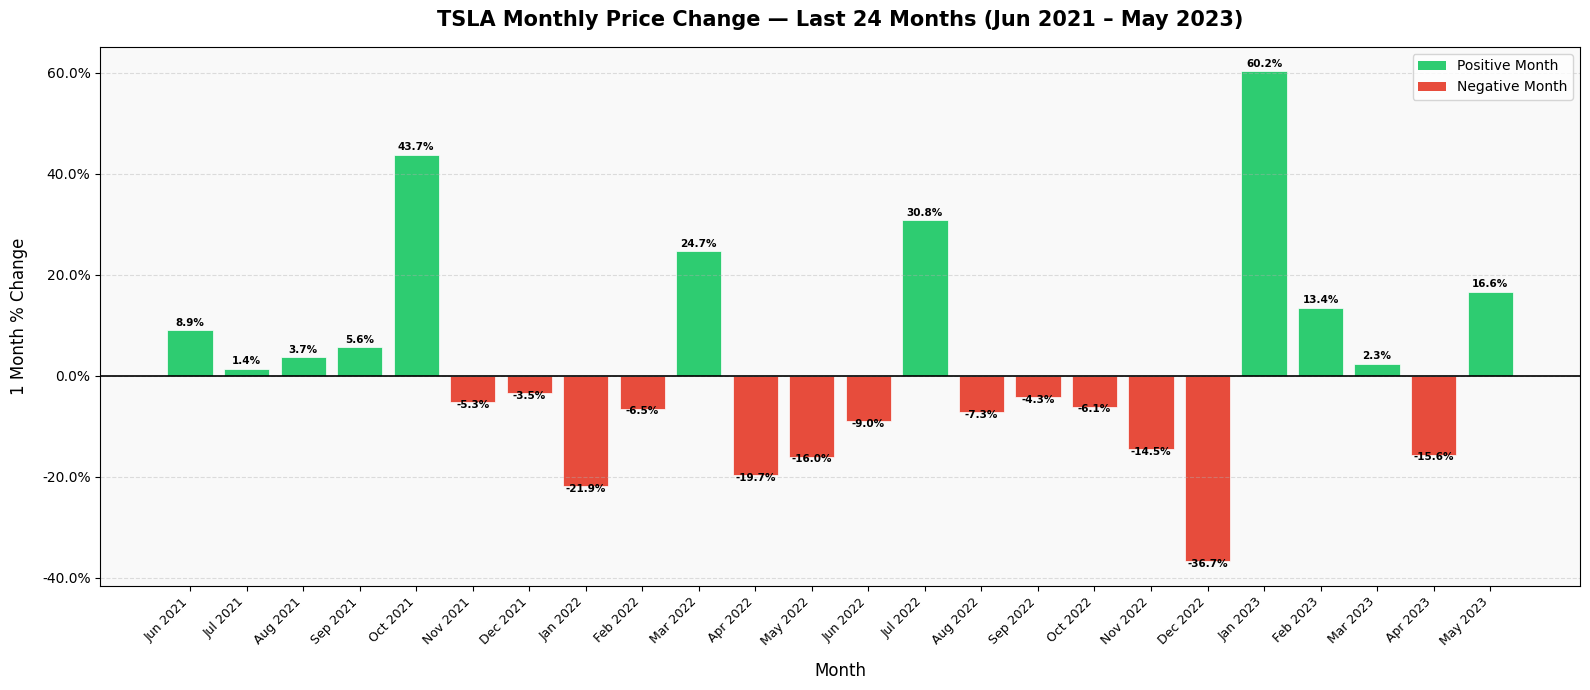

In [9]:
colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in last_24['1monthchange']]

fig, ax = plt.subplots(figsize=(16, 7))
bars = ax.bar(last_24['MonthLabel'], last_24['1monthchange'],
              color=colors, edgecolor='white', linewidth=0.5)

ax.axhline(0, color='black', linewidth=1.2)

# Value labels on each bar
for bar, val in zip(bars, last_24['1monthchange']):
    offset = 0.5 if val >= 0 else -1.5
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + offset,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.set_title('TSLA Monthly Price Change — Last 24 Months (Jun 2021 – May 2023)',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=12, labelpad=10)
ax.set_ylabel('1 Month % Change', fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax.grid(axis='y', alpha=0.4, linestyle='--')
ax.set_facecolor('#f9f9f9')

legend_elements = [Patch(facecolor='#2ecc71', label='Positive Month'),
                   Patch(facecolor='#e74c3c', label='Negative Month')]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.tight_layout()

# Save for Flask
os.makedirs('static/graphs', exist_ok=True)
plt.savefig('static/graphs/tsla_monthly_chart.png', dpi=150, bbox_inches='tight')
print('✅ Chart saved to static/graphs/tsla_monthly_chart.png')
plt.show()

---
## STEP 8: Summary Statistics

In [10]:
best_idx  = last_24['1monthchange'].idxmax()
worst_idx = last_24['1monthchange'].idxmin()

print('=== TSLA — Last 24 Months Summary ===')
print(f"Period        : {last_24['MonthLabel'].iloc[0]} → {last_24['MonthLabel'].iloc[-1]}")
print(f"Best  Month   : {last_24.loc[best_idx, 'MonthLabel']}  →  +{last_24['1monthchange'].max():.2f}%")
print(f"Worst Month   : {last_24.loc[worst_idx, 'MonthLabel']}  →  {last_24['1monthchange'].min():.2f}%")
print(f"Average Change: {last_24['1monthchange'].mean():.2f}%")
print(f"Positive Months: {(last_24['1monthchange'] > 0).sum()} / 24")
print(f"Negative Months: {(last_24['1monthchange'] < 0).sum()} / 24")
print(f"Total Trading Days in dataset: 3,049")

=== TSLA — Last 24 Months Summary ===
Period        : Jun 2021 → May 2023
Best  Month   : Jan 2023  →  +60.24%
Worst Month   : Dec 2022  →  -36.73%
Average Change: 1.86%
Positive Months: 11 / 24
Negative Months: 13 / 24
Total Trading Days in dataset: 3,049


In [11]:
import sqlite3

# Create/connect SQLite database
conn = sqlite3.connect("tsla_stock.db")

# Store final dataframe into database table
df.to_sql("tsla_stock_data", conn, if_exists="replace", index=False)

conn.close()

print("✅ Data successfully stored in SQLite database: tsla_stock.db")

✅ Data successfully stored in SQLite database: tsla_stock.db


In [12]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("tsla_stock.db")

db_df = pd.read_sql_query("SELECT * FROM tsla_stock_data LIMIT 10", conn)

conn.close()

db_df

,Date,Adj Close,% change,1monthchange
0,2011-04-12 00:00:00,1.643333,NaN,None
1,2011-04-13 00:00:00,1.662000,1.1359,None
2,2011-04-14 00:00:00,1.676000,0.8424,None
3,2011-04-15 00:00:00,1.705333,1.7502,None
4,2011-04-18 00:00:00,1.668667,-2.1501,None
5,2011-04-19 00:00:00,1.677333,0.5193,None
6,2011-04-20 00:00:00,1.716667,2.3450,None
7,2011-04-21 00:00:00,1.782667,3.8447,None
8,2011-04-25 00:00:00,1.759333,-1.3089,None
9,2011-04-26 00:00:00,1.795333,2.0462,None


In [13]:
conn = sqlite3.connect("tsla_stock.db")

monthly_db = pd.read_sql_query("""
SELECT *
FROM tsla_stock_data
WHERE "1monthchange" IS NOT NULL
ORDER BY Date
""", conn)

conn.close()

monthly_db.tail(24)

,Date,Adj Close,% change,1monthchange
122,2021-06-30 00:00:00,226.566666,-0.1557,8.9437
123,2021-07-30 00:00:00,229.066666,1.4542,1.3689
124,2021-08-31 00:00:00,245.240005,0.6581,3.6707
125,2021-09-30 00:00:00,258.493347,-0.7462,5.6383
126,2021-10-29 00:00:00,371.333344,3.4316,43.7011
127,2021-11-30 00:00:00,381.586670,0.6834,-5.2814
128,2021-12-31 00:00:00,352.260010,-1.2669,-3.4904
129,2022-01-31 00:00:00,312.239990,10.6776,-21.9257
130,2022-02-28 00:00:00,290.143341,7.4777,-6.5310
131,2022-03-31 00:00:00,359.200012,-1.4982,24.6688
